<a href="https://colab.research.google.com/github/pranjaldwivedii001-commits/Regression_Model/blob/main/Regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from sklearn import set_config

# This forces the diagram to be a static image instead of interactive HTML
set_config(display='diagram')

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv("/content/train.csv")

In [12]:
df.head()

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068,Turbine_01,54.346095


In [13]:
df.shape

(7575, 16)

In [14]:
display(df.head())
display(df.info())
display(df.describe())

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068,Turbine_01,54.346095


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7575 entries, 0 to 7574
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   timestamp                               7575 non-null   object 
 1   active_power_calculated_by_converter    7575 non-null   float64
 2   active_power_raw                        7575 non-null   float64
 3   ambient_temperature                     7575 non-null   float64
 4   generator_speed                         7575 non-null   float64
 5   generator_winding_temp_max              7575 non-null   float64
 6   grid_power10min_average                 7575 non-null   float64
 7   nc1_inside_temp                         7575 non-null   float64
 8   nacelle_temp                            7575 non-null   float64
 9   reactice_power_calculated_by_converter  7575 non-null   float64
 10  reactive_power                          7575 non-null   floa

None

,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,Target
count,7575.000000,7575.000000,7575.000000,7575.000000,7575.000000,7575.000000,7575.000000,7575.000000,7575.000000,7575.000000,7575.000000,7575.000000,7575.000000,7574.000000
mean,531.546964,542.813467,25.608910,934.189315,60.673016,532.313170,31.727666,31.642251,111.771446,134.442354,199.834334,5.915933,0.652311,46.288029
std,478.798180,486.180220,8.054582,189.719470,9.879945,477.047391,4.004444,3.572683,79.594396,92.679138,104.328646,1.996911,0.305242,2.681443
min,0.005207,0.026303,6.505799,0.000000,30.324467,0.053424,11.446849,17.417674,-4.875317,-3.296051,1.127336,0.939861,0.086543,26.284803
25%,152.904653,159.598170,17.140684,770.538574,54.844991,152.350252,29.892118,30.211312,81.369957,96.092192,99.909785,4.414411,0.434771,44.730292
50%,386.285868,390.846313,27.960740,889.488611,60.016169,396.182656,31.763659,31.910693,91.978521,107.558136,232.221252,5.641069,0.588827,46.229183
75%,791.220083,810.096069,32.163621,1126.799500,65.734139,803.224716,33.471027,33.478718,125.227813,154.234898,287.190432,7.111914,0.803247,47.712395
max,1999.548075,1999.740662,46.237511,1205.028564,115.206192,1999.526402,51.578794,47.954105,484.817581,558.456573,359.455531,19.129167,3.203567,64.958340


In [15]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year

air_density = 1.225
df['wind_power_density'] = 0.5 * air_density * (df['wind_speed_raw']**3)

display(df.head())

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,...,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target,hour,day_of_week,month,year,wind_power_density
0,2021-02-19 20:18:00,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,...,280.864782,7.057000,0.544082,Turbine_108,47.582787,20,4,2,2021,215.261541
1,2021-04-27 04:55:00,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,...,299.552460,5.474937,0.469031,Turbine_18,46.070328,4,1,4,2021,100.517922
2,2021-01-25 06:26:00,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,...,84.960106,8.092457,0.622318,Turbine_105,39.989236,6,0,1,2021,324.599132
3,2021-10-30 03:47:00,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,...,87.261119,4.071032,0.760719,Turbine_15,46.056587,3,5,10,2021,41.325642
4,2021-03-15 00:39:00,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,...,313.724818,6.357943,0.346068,Turbine_01,54.346095,0,0,3,2021,157.418570


Visualize the relationship between the categorical feature and the target variable.

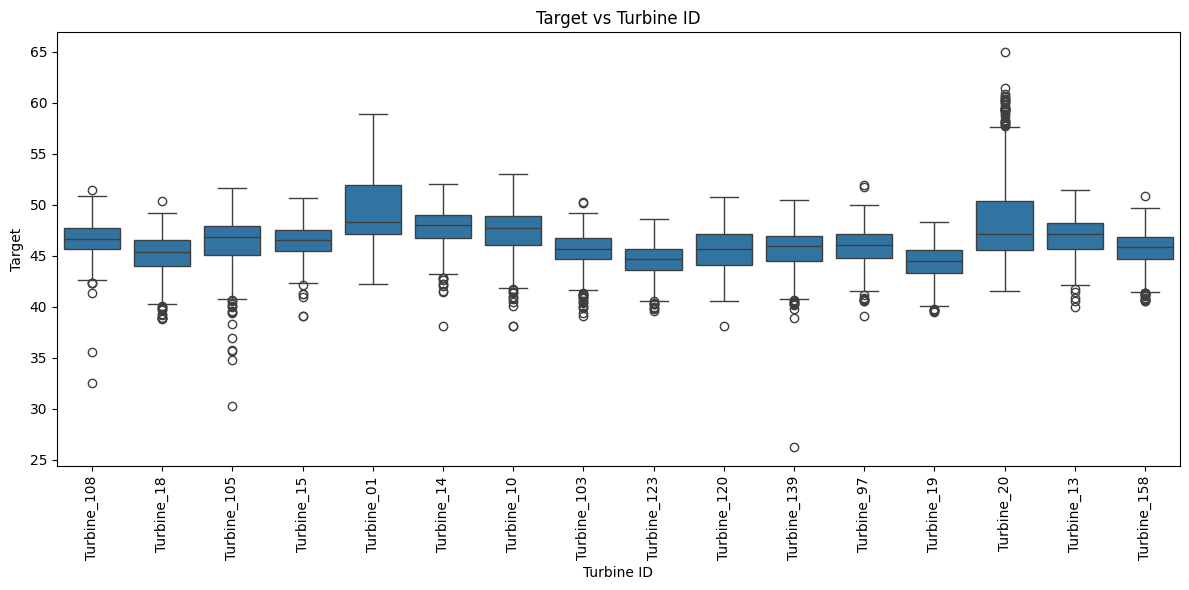

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='turbine_id', y='Target')
plt.title('Target vs Turbine ID')
plt.xlabel('Turbine ID')
plt.ylabel('Target')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## VISUALISATION

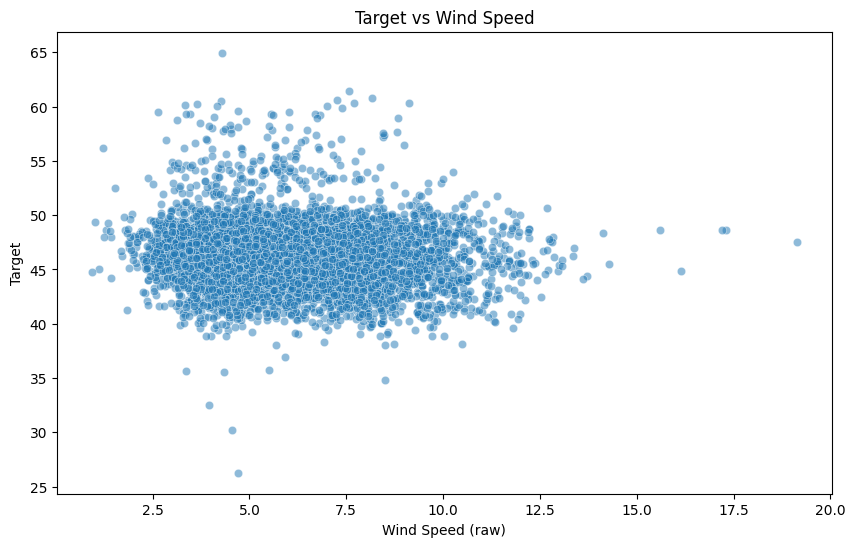

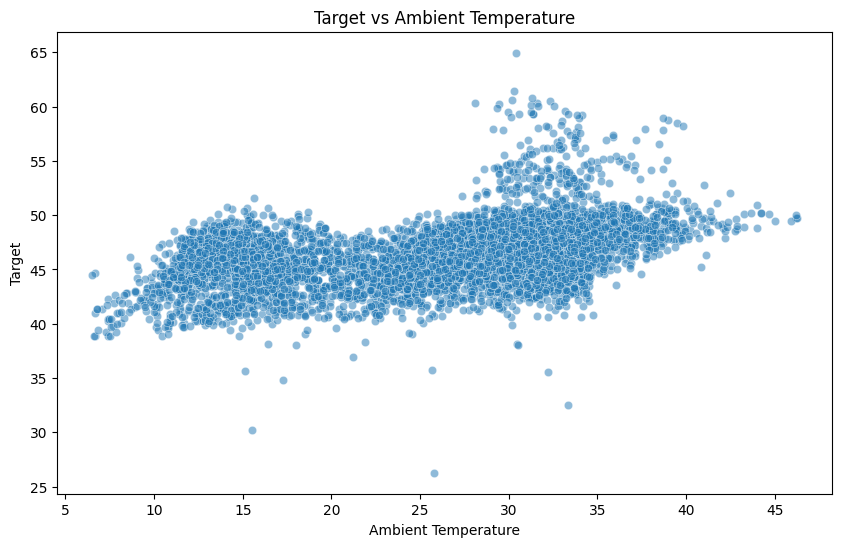

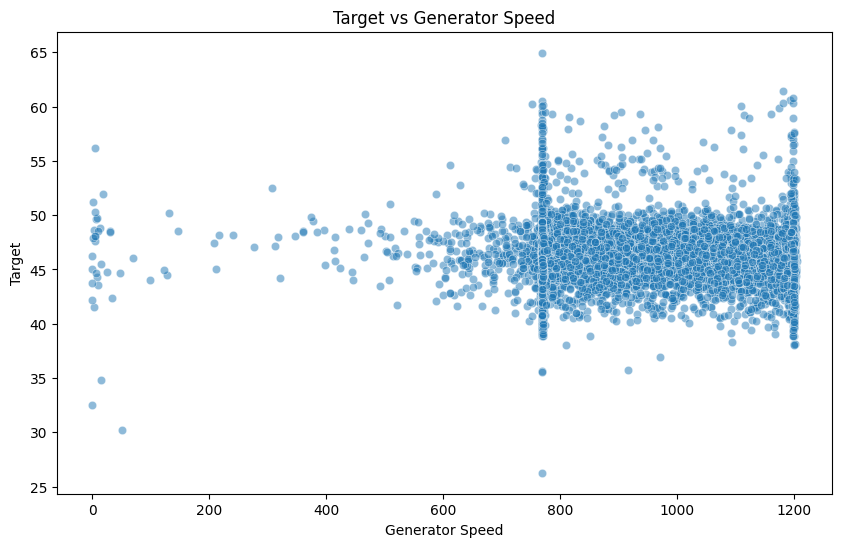

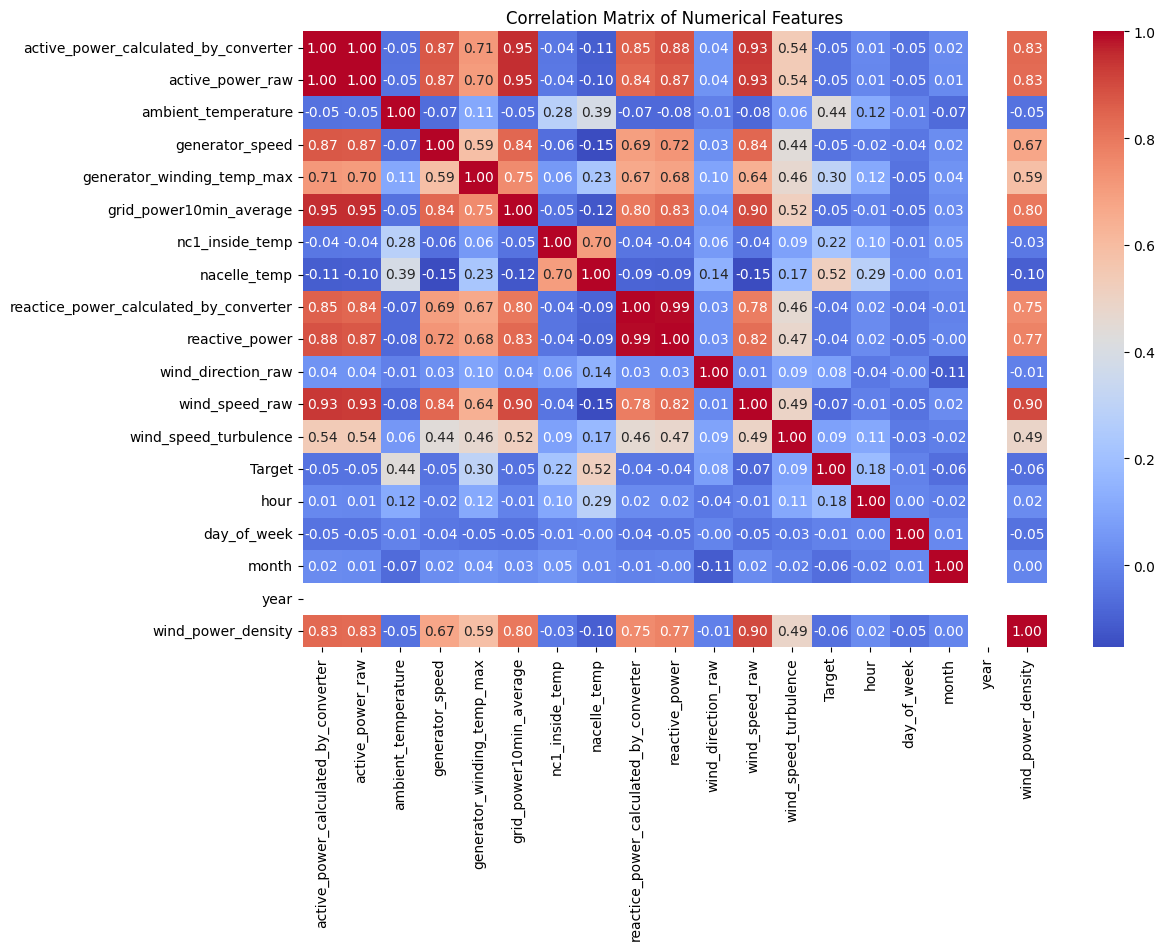

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='wind_speed_raw', y='Target', alpha=0.5)
plt.title('Target vs Wind Speed')
plt.xlabel('Wind Speed (raw)')
plt.ylabel('Target')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ambient_temperature', y='Target', alpha=0.5)
plt.title('Target vs Ambient Temperature')
plt.xlabel('Ambient Temperature')
plt.ylabel('Target')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='generator_speed', y='Target', alpha=0.5)
plt.title('Target vs Generator Speed')
plt.xlabel('Generator Speed')
plt.ylabel('Target')
plt.show()


numerical_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Target vs Wind Speed: You most likely see a strong positive correlation. As wind speed increases, the target (power output) generally increases.

Target vs Ambient Temperature: The relationship here is often less clear or weaker compared to wind speed. You might see a slight negative correlation or no strong pattern.

Target vs Generator Speed: You likely see a strong positive correlation. As the generator speed increases, the power output also increases.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [19]:
X = df.drop(['timestamp', 'Target', 'active_power_raw', 'reactive_power'], axis=1)
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
numeric_feature = ['wind_speed_raw', 'ambient_temperature', 'generator_speed']
categorical_feature = ['turbine_id']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_feature),
        ('cat', categorical_transformer, categorical_feature)
    ])

In [21]:
nan_mask_y_train = y_train.isna()
X_train_cleaned = X_train[~nan_mask_y_train]
y_train_cleaned = y_train[~nan_mask_y_train]

In [22]:
model = Pipeline(steps=[('preprocessor', preprocessor),
                      ('regressor', LinearRegression())])
model.fit(X_train_cleaned, y_train_cleaned)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['wind_speed_raw',
                                                   'ambient_temperature',
                                                   'generator_speed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['turbine_id'])])),
                ('regressor', LinearRegression())])

In [23]:
y_pred = model.predict(X_test)

In [24]:
mse_linear = mean_squared_error(y_test, y_pred)
r2_linear = r2_score(y_test, y_pred)

print("Linear Regression Model:")
print(f"Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"R-squared (R2): {r2_linear:.2f}")

Linear Regression Model:
Mean Squared Error (MSE): 5.07
R-squared (R2): 0.35


In [17]:
rf_model = Pipeline(steps=[('preprocessor', preprocessor),
                      ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))])

rf_model.fit(X_train_cleaned, y_train_cleaned)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['wind_speed_raw',
                                                   'ambient_temperature',
                                                   'generator_speed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['turbine_id'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [24]:
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Model:")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

print("\nLinear Regression Model (for comparison):")
print(f"Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"R-squared (R2): {r2_linear:.2f}")

Random Forest Regressor Model:
Mean Squared Error (MSE): 4.20
R-squared (R2): 0.44

Linear Regression Model (for comparison):
Mean Squared Error (MSE): 4.75
R-squared (R2): 0.37


Linear Regression Model:


MSE: 4.75
R-squared: 0.37
Insight: The Linear Regression model has an average squared error of about 4.75 and explains about 57% of the variance in the 'Target' variable. This indicates a moderate level of predictive capability, but there's still a significant portion of the target's variability that the linear model isn't capturing.

Random Forest Regressor Model:
MSE: 4.20
R-squared: 0.44
Insight: The Random Forest Regressor model has a lower MSE (4.20) and a higher R-squared (0.44) compared to the Linear Regression model. This is a key insight: the Random Forest model is performing better. It has smaller average errors and explains a larger proportion (65%) of the variance in the target variable.

In [21]:
y_pred_rf

array([43.30069147, 45.88270002, 45.97353101, ..., 45.30786771,
       51.32561125, 47.54319274])

In [22]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

In [23]:
ridge_model = Pipeline(steps=[('preprocessor', preprocessor),
                      ('regressor', Ridge(alpha=1.0))])

ridge_model.fit(X_train_cleaned, y_train_cleaned)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['wind_speed_raw',
                                                   'ambient_temperature',
                                                   'generator_speed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['turbine_id'])])),
                ('regressor', Ridge())])

In [3]:
lasso_model = Pipeline(steps=[('preprocessor', preprocessor),
                      ('regressor', Lasso(alpha=1.0))])

lasso_model.fit(X_train_cleaned, y_train_cleaned)

NameError: name 'Pipeline' is not defined

In [25]:
elnet_model = Pipeline(steps=[('preprocessor', preprocessor),
                      ('regressor', ElasticNet(alpha=1.0))])

elnet_model.fit(X_train_cleaned, y_train_cleaned)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['wind_speed_raw',
                                                   'ambient_temperature',
                                                   'generator_speed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['turbine_id'])])),
                ('regressor', ElasticNet())])

In [26]:
y_pred_ridge = ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

In [27]:
y_pred_lasso = lasso_model.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

In [28]:
y_pred_elnet = elnet_model.predict(X_test)
mse_elnet = mean_squared_error(y_test, y_pred_elnet)
r2_elnet = r2_score(y_test, y_pred_elnet)

In [29]:
print("Ridge Regressor Model:")
print(f"Mean Squared Error (MSE): {mse_ridge:.2f}")
print(f"R-squared (R2): {r2_ridge:.2f}")

print("\nLasso Regressor Model:")
print(f"Mean Squared Error (MSE): {mse_lasso:.2f}")
print(f"R-squared (R2): {r2_lasso:.2f}")

print("\nElnet Model (for comparison):")
print(f"Mean Squared Error (MSE): {mse_elnet:.2f}")
print(f"R-squared (R2): {r2_elnet:.2f}")

Ridge Regressor Model:
Mean Squared Error (MSE): 4.35
R-squared (R2): 0.37

Lasso Regressor Model:
Mean Squared Error (MSE): 6.70
R-squared (R2): 0.03

Elnet Model (for comparison):
Mean Squared Error (MSE): 6.19
R-squared (R2): 0.11


In [31]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the pipeline for the Random Forest Regressor
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', RandomForestRegressor(random_state=42))])

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'regressor__n_estimators': randint(100, 500), # Number of trees in the forest
    'regressor__max_features': ['sqrt', 'log2', None], # Number of features to consider at every split
    'regressor__max_depth': randint(10, 100), # Maximum number of levels in tree
    'regressor__min_samples_split': randint(2, 20), # Minimum number of samples required to split a node
    'regressor__min_samples_leaf': randint(1, 10), # Minimum number of samples required at each leaf node
    'regressor__bootstrap': [True, False] # Method of selecting samples for training each tree
}

# Instantiate RandomizedSearchCV
random_search_rf = RandomizedSearchCV(estimator=rf_pipeline,
                                      param_distributions=param_dist,
                                      n_iter=50, # Number of parameter settings that are sampled
                                      cv=3, # Number of cross-validation folds
                                      verbose=2,
                                      random_state=42,
                                      n_jobs=-1, # Use all available cores
                                      scoring='neg_mean_squared_error')

# Fit RandomizedSearchCV to the training data
random_search_rf.fit(X_train_cleaned, y_train_cleaned)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer()),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['wind_speed_raw',
                                                                                'ambient_temperature',
                                                                                'generator_speed']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot',
                                                                                                OneHotEncoder(handle_unkno...
                                        'regressor__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f85746dfc50>,
                                        'regressor__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f85746dc9b0>,
                                        'regressor__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f8575aa77d0>},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [32]:
# Print the best parameters and the best score found
print("Best parameters found: ", random_search_rf.best_params_)
print("Best MSE found: ", -random_search_rf.best_score_)

# Evaluate the best Random Forest model found by RandomizedSearchCV
best_rf_model = random_search_rf.best_estimator_
y_pred_tuned_rf = best_rf_model.predict(X_test)

mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print("\nTuned Random Forest Regressor Model:")
print(f"Mean Squared Error (MSE): {mse_tuned_rf:.2f}")
print(f"R-squared (R2): {r2_tuned_rf:.2f}")

print("\nOriginal Random Forest Regressor Model (for comparison):")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")

Best parameters found:  {'regressor__bootstrap': True, 'regressor__max_depth': 69, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 445}
Best MSE found:  3.772829562110362

Tuned Random Forest Regressor Model:
Mean Squared Error (MSE): 3.91
R-squared (R2): 0.48

Original Random Forest Regressor Model (for comparison):
Mean Squared Error (MSE): 4.20
R-squared (R2): 0.44


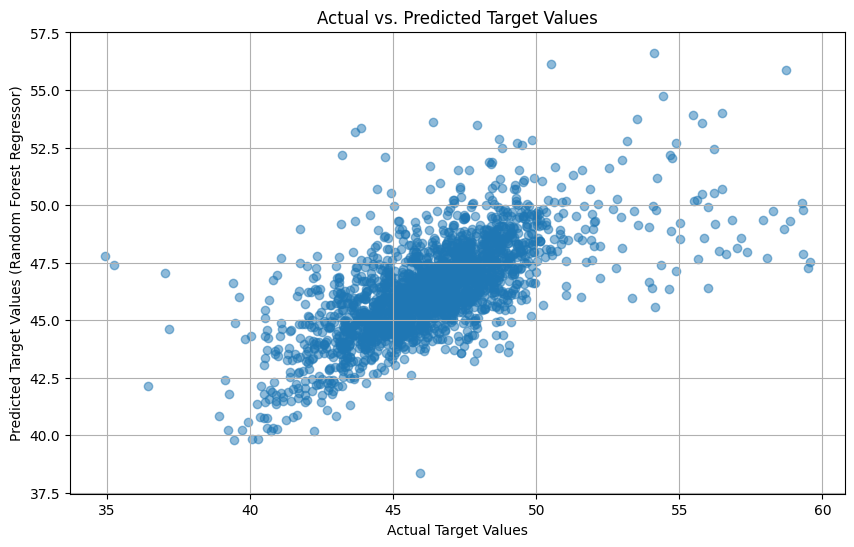

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Target Values")
plt.ylabel("Predicted Target Values (Random Forest Regressor)")
plt.title("Actual vs. Predicted Target Values")
plt.grid(True)
plt.show()